# Metricas que se van a usar para la evalución de los modelos basados en léxicos

## VADER
Vader al ser un modelo basado en valencias, lo normal sería usar métricas continuas como el MAE, MSE, RMSE, R^2 y MAPE si contamos las estrellas como un rango continuo [0, 5]. Además de esto, podríamos utilizar las 5 estrellas como 5 categorías y utilizar Cohens Kappa para ver también como clasífica este modelo realizando una aproximación de la valencia a la categoría más cercana. También podriamos dividir las estrellas en una clasificación binaria, con dos clases que serían positivas (2,5 a 5 estrellas) o negativas (0 a 2,5 estrellas) y ver también como se comportaría el modelo en clasificación binaria (accuracy, precision, F1-SCORE...)

## AFINN
Lo mismo que VADER ya que se comporta igual

## NRC
NRC es bastante diferente, ya que los valores más importantes que da este modelo son los sentiminetos asociados a cada reseña, cosa que no se puede evaluar cuantitativamente ya que no tenemos un valor objetivo. Lo suyo sería realizar un análisis no tanto de precisión sino cualitativo, para ver como se asocian las emociones con los valores de las estrellas o palabras específicas.


In [1]:
import polars as pl
import polars_ds as pds
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [29]:
def regression_metrics(csv_with_scores):
    """
    Calcular las métricas asociadas a problemas de regresión (MAE, MSE, RMSE) para los dos modelos basados en valencia (VADER y AFINN)
    """
    
    df = pl.scan_csv(csv_with_scores)

    # Calcular los principales errores y el coeficiente de Spearman
    metricas_vader = df.select([
        (pl.col("stars") - pl.col("vader_score")).abs().mean().alias("MAE_vader"),
        (pl.col("stars") - pl.col("vader_score")).pow(2).mean().alias("MSE_vader"),
        (pl.col("stars") - pl.col("vader_score")).pow(2).mean().sqrt().alias("RMSE_vader"),
        pl.corr("stars", "vader_score", method="spearman").alias("Spearman_vader")
    ]).collect()
    
    metricas_afinn = df.select([
        (pl.col("stars") - pl.col("afinn_score")).abs().mean().alias("MAE_afinn"),
        (pl.col("stars") - pl.col("afinn_score")).pow(2).mean().alias("MSE_afinn"),
        (pl.col("stars") - pl.col("afinn_score")).pow(2).mean().sqrt().alias("RMSE_afinn"),
        pl.corr("stars", "afinn_score", method="spearman").alias("Spearman_afinn")
    ]).collect()

    df_metricas = pl.DataFrame({
        "Metrica":  ["MAE", "MSE", "RMSE", "Spearman"],
        "Vader": [
            metricas_vader["MAE_vader"].item(),
            metricas_vader["MSE_vader"].item(),
            metricas_vader["RMSE_vader"].item(),
            metricas_vader["Spearman_vader"].item()
        ],
        "Afinn": [
            metricas_afinn["MAE_afinn"].item(),
            metricas_afinn["MSE_afinn"].item(),
            metricas_afinn["RMSE_afinn"].item(),
            metricas_afinn["Spearman_afinn"].item()
        ]}).to_pandas()

    df_metricas = df_metricas.set_index("Metrica")    
    
    print("Métricas de regresión de VADER:")
    print(metricas_vader)

    print("Métricas de regresión de AFINN:")
    print(metricas_afinn)

    df_metricas.plot(kind='bar', figsize=(10, 6), color=['royalblue', 'darkorange'])
    plt.title('Comparativa de Métricas de Regresión')
    plt.ylabel('Puntuación')
    plt.xticks(rotation=0)
    plt.show()

In [3]:
def binary_classification_metrics(csv_with_scores):
    """
    Calcular las métricas asociada a la clasificación binaría para los dos modelos basados en valencias.
    Antes que nada se realiza una categorización de los resultados de VADER y AFINN a 1/0 para tomarlo como clasificación binaría
    """
    df = pl.scan_csv(csv_with_scores)

    # Eliminar las reseñas que tengan 3 estrellas (para esta parte me apoyo en los trabajos apuntados que utilizan esta vía)
    df_clean = df.with_columns([
        pl.col("stars"),
        pl.col("vader_score"),
        pl.col("afinn_score")
    ]).filter(pl.col("stars") != 3)

    df_ready = df_clean.with_columns([
        (pl.col("stars") >= 4).cast(pl.UInt32).alias("stars_binary")
    ])

    # Calcular las métricas clásicas de clasificación binaria y las matrices de confusión
    metricas_finales = df_ready.select([
        pds.query_binary_metrics(
            "stars_binary", 
            "vader_score", 
            threshold=3.0
        ).alias("VADER_metrics"),
        
        pds.query_binary_metrics(
            "stars_binary", 
            "afinn_score", 
            threshold=3.0
        ).alias("AFINN_metrics"),
        
        
        pds.query_confusion_matrix(
            "stars_binary",
            "vader_score",
            threshold=3.0
        ).alias("VADER_confusion_matrix"),
        

        pds.query_confusion_matrix(
            "stars_binary",
            "afinn_score",
            threshold=3.0
        ).alias("AFINN_confusion_matrix")
        ])

    resultados = metricas_finales.collect()

    print("Métricas de clasificación binaría de VADER:")
    print(resultados.select(pl.col("VADER_metrics")).unnest("VADER_metrics"))
                            
    print("Métricas de clasificación binaría de AFINN")
    print(resultados.select(pl.col("AFINN_metrics")).unnest("AFINN_metrics"))

    # Diccionario que guarden las métricas de clasificación binaria
    vader_metrics_dict = resultados.select(pl.col("VADER_metrics")).unnest("VADER_metrics").to_dicts()[0]
    afinn_metrics_dict = resultados.select(pl.col("AFINN_metrics")).unnest("AFINN_metrics").to_dicts()[0]

    # Transformar los dos diccionarios en un df para mostralos juntos en un mismo gráfico
    df_metricas_pd = pd.DataFrame({
        "Metrica": ["Precision", "Recall", "F1_Score", "ROC_AUC"],
        "VADER": [
            vader_metrics_dict["precision"], 
            vader_metrics_dict["recall"], 
            vader_metrics_dict["f"], 
            vader_metrics_dict["roc_auc"]
        ],
        "AFINN": [
            afinn_metrics_dict["precision"], 
            afinn_metrics_dict["recall"], 
            afinn_metrics_dict["f"], 
            afinn_metrics_dict["roc_auc"]
        ]
    }).set_index("Metrica")

    # Mostrar un histograma que represente las diferentes métricas
    df_metricas_pd.plot(kind='bar', figsize=(10, 6), color=['royalblue', 'darkorange'])
    plt.title('Comparativa de Métricas de Clasificación Binaria')
    plt.ylabel('Puntuación')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=0)
    plt.show()

    # Diccionarios que representan las matrices de confusión
    vader_cm_dict = resultados.select(pl.col("VADER_confusion_matrix")).unnest("VADER_confusion_matrix").to_dicts()[0]
    afinn_cm_dict = resultados.select(pl.col("AFINN_confusion_matrix")).unnest("AFINN_confusion_matrix").to_dicts()[0]

    # Transformar los diccionarios en matrices 2x2 para poder utilizarlas con seaborn
    matriz_vader_2x2 = np.array([
        [int(vader_cm_dict["tn"]), int(vader_cm_dict["fp"])],
        [int(vader_cm_dict["fn"]), int(vader_cm_dict["tp"])]
    ])

    matriz_afinn_2x2 = np.array([
        [int(afinn_cm_dict["tn"]), int(afinn_cm_dict["fp"])],
        [int(afinn_cm_dict["fn"]), int(afinn_cm_dict["tp"])]
    ])

    # Pintar las matrices de confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_vader_2x2, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negativo Pred.", "Positivo Pred."],
                yticklabels=["Negativo Real", "Positivo Real"])
    plt.title("Matriz confusión VADER")
    plt.show()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_afinn_2x2, annot=True, fmt="d", cmap="Oranges",
                xticklabels=["Negativo Pred.", "Positivo Pred."],
                yticklabels=["Negativo Real", "Positivo Real"])
    plt.title("Matriz confusión AFINN")
    plt.show()

In [31]:
def encode_3_class(col_name):
    """
    Categoriza los resultados de VADER y AFINN en 3 categorías (Positivo, Neutral y Negativo)
    """
    return (pl.when(pl.col(col_name) < 2.5).then(0).when(pl.col(col_name) >= 3.5).then(2).otherwise(1)).cast(pl.Int32)

def build_matrix_3x3(df_grouped, col_prediccion):
    """
    Construir la matriz de confusión 3x3 para alguno de los modelos
    """
    matriz = np.zeros((3, 3), dtype=int)
    for row in df_grouped.iter_rows(named=True):
        real = row["stars_3c"]
        pred = row[col_prediccion]
        if 0 <= real <= 2 and 0 <= pred <= 2:
            matriz[real, pred] = row["len"]
    return matriz

def calculate_multiclass_metrics(matriz):
    """
    Calcular las métricas típicas de los problemas de clasificación dentro de una clasificación de 3 clases(Accuracy, Precicion, recall, f1)
    """
    # Teniendo en cuenta que es una matriz 3x3
    tp = np.diag(matriz)
    fp = matriz.sum(axis=0) - tp
    fn = matriz.sum(axis=1) - tp
    
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp+fp)!=0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0)
    f1 = np.divide(2 * (precision * recall), (precision + recall), out=np.zeros_like(tp, dtype=float), where=(precision+recall)!=0)
        
    accuracy = np.trace(matriz) / np.sum(matriz)
    macro_f1 = np.mean(f1)
        
    return precision, recall, f1, accuracy, macro_f1

def multiclass_classification_metrics(csv_with_scores):
    """
    Calcula y realiza un análisis completo de todas las métricas representativas de problemas multiclase para los modelos AFINN y VADER
    """
    df = pl.scan_csv(csv_with_scores)

    # Transformar los valores continuos a 3 clases
    df_3c = df.with_columns([
        encode_3_class("stars").alias("stars_3c"),
        encode_3_class("vader_score").alias("vader_3c"),
        encode_3_class("afinn_score").alias("afinn_3c")
    ])

    
    cm_vader_data = df_3c.group_by(["stars_3c", "vader_3c"]).len().collect()
    
    cm_afinn_data = df_3c.group_by(["stars_3c", "afinn_3c"]).len().collect()

    # Construir las dos matrices de confusión
    matriz_vader = build_matrix_3x3(cm_vader_data, "vader_3c")
    matriz_afinn = build_matrix_3x3(cm_afinn_data, "afinn_3c")

    # Calcular las diferentes métricas de clasificación
    precision_vader, recall_vader, f1_vader, accuracy_vader, mf1_vader = calculate_multiclass_metrics(matriz_vader)
    precision_afinn, recall_afinn, f1_afinn, accuracy_afinn, mf1_afinn = calculate_multiclass_metrics(matriz_afinn)

    print("Métricas clasificación multiclase VADER:")
    print(f"Accuracy: {accuracy_vader:.3f} | Macro F1: {mf1_vader:.3f}")
    print(f"Precision por clase -> Negativo: {precision_vader[0]:.3f}, Neutro: {precision_vader[1]:.3f}, Positivo: {precision_vader[2]:.3f}")

    print("\nMétricas clasificación multiclase AFINN:")
    print(f"Accuracy: {accuracy_afinn:.3f} | Macro F1: {mf1_afinn:.3f}")
    print(f"Precision por clase -> Negativo: {precision_afinn[0]:.3f}, Neutro: {precision_afinn[1]:.3f}, Positivo: {precision_afinn[2]:.3f}")


    clases = ["Negativo", "Neutro", "Positivo"]

    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_vader, annot=True, fmt="d", cmap="Blues", xticklabels=clases, yticklabels=clases)
    plt.title("Matriz de Confusión 3x3 - VADER")
    plt.xlabel("Predicción")
    plt.ylabel("Realidad")
    plt.show()

    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_afinn, annot=True, fmt="d", cmap="Oranges", 
                xticklabels=clases, yticklabels=clases)
    plt.title("Matriz de Confusión 3x3 - AFINN")
    plt.xlabel("Predicción")
    plt.ylabel("Realidad")
    plt.show()

    x = np.arange(len(clases))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, f1_vader, width, label='VADER', color='royalblue')
    plt.bar(x + width/2, f1_afinn, width, label='AFINN', color='darkorange')
    
    plt.ylabel('F1-Score')
    plt.title('F1-Score por categoría')
    plt.xticks(x, clases)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.show()

Métricas de regresión de VADER:
shape: (1, 4)
┌───────────┬───────────┬────────────┬────────────────┐
│ MAE_vader ┆ MSE_vader ┆ RMSE_vader ┆ Spearman_vader │
│ ---       ┆ ---       ┆ ---        ┆ ---            │
│ f64       ┆ f64       ┆ f64        ┆ f64            │
╞═══════════╪═══════════╪════════════╪════════════════╡
│ 0.813329  ┆ 1.521367  ┆ 1.233437   ┆ 0.512293       │
└───────────┴───────────┴────────────┴────────────────┘
Métricas de regresión de AFINN:
shape: (1, 4)
┌───────────┬───────────┬────────────┬────────────────┐
│ MAE_afinn ┆ MSE_afinn ┆ RMSE_afinn ┆ Spearman_afinn │
│ ---       ┆ ---       ┆ ---        ┆ ---            │
│ f64       ┆ f64       ┆ f64        ┆ f64            │
╞═══════════╪═══════════╪════════════╪════════════════╡
│ 0.848419  ┆ 1.628902  ┆ 1.276284   ┆ 0.482755       │
└───────────┴───────────┴────────────┴────────────────┘


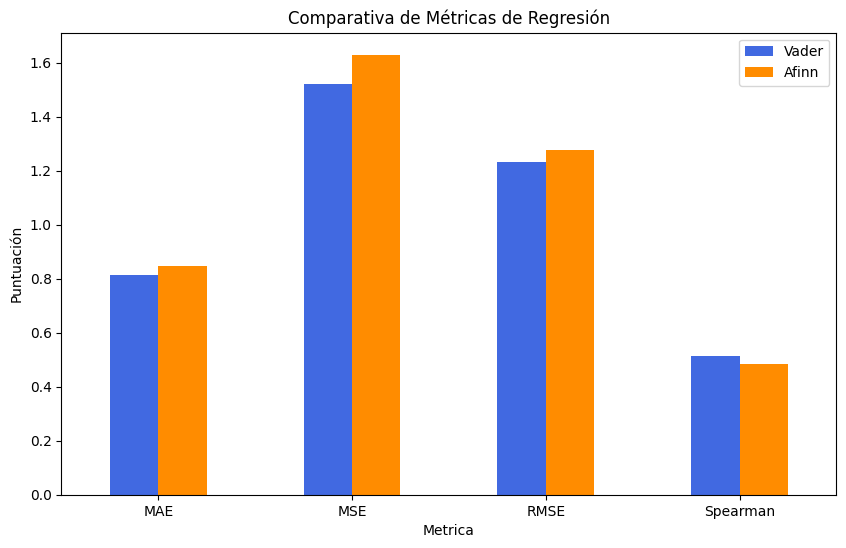

Métricas de clasificación binaría de VADER:
shape: (1, 5)
┌───────────┬──────────┬─────────┬───────────────┬──────────┐
│ precision ┆ recall   ┆ f       ┆ avg_precision ┆ roc_auc  │
│ ---       ┆ ---      ┆ ---     ┆ ---           ┆ ---      │
│ f64       ┆ f64      ┆ f64     ┆ f64           ┆ f64      │
╞═══════════╪══════════╪═════════╪═══════════════╪══════════╡
│ 0.858711  ┆ 0.980952 ┆ 0.91577 ┆ 0.941913      ┆ 0.889119 │
└───────────┴──────────┴─────────┴───────────────┴──────────┘
Métricas de clasificación binaría de AFINN
shape: (1, 5)
┌───────────┬─────────┬──────────┬───────────────┬──────────┐
│ precision ┆ recall  ┆ f        ┆ avg_precision ┆ roc_auc  │
│ ---       ┆ ---     ┆ ---      ┆ ---           ┆ ---      │
│ f64       ┆ f64     ┆ f64      ┆ f64           ┆ f64      │
╞═══════════╪═════════╪══════════╪═══════════════╪══════════╡
│ 0.841942  ┆ 0.98416 ┆ 0.907513 ┆ 0.935563      ┆ 0.876487 │
└───────────┴─────────┴──────────┴───────────────┴──────────┘


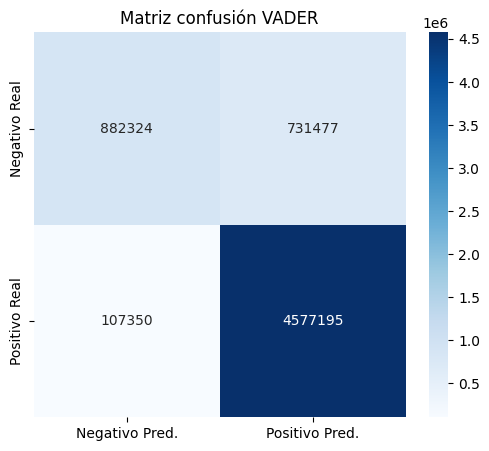

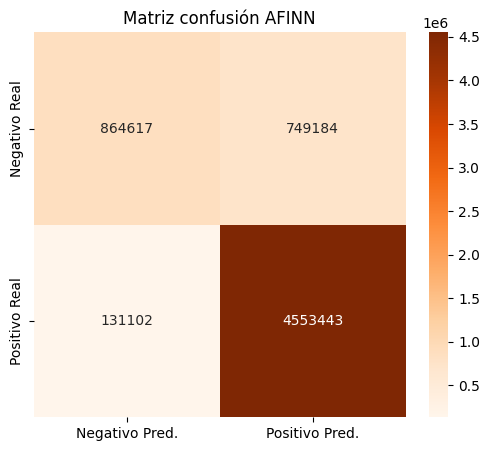

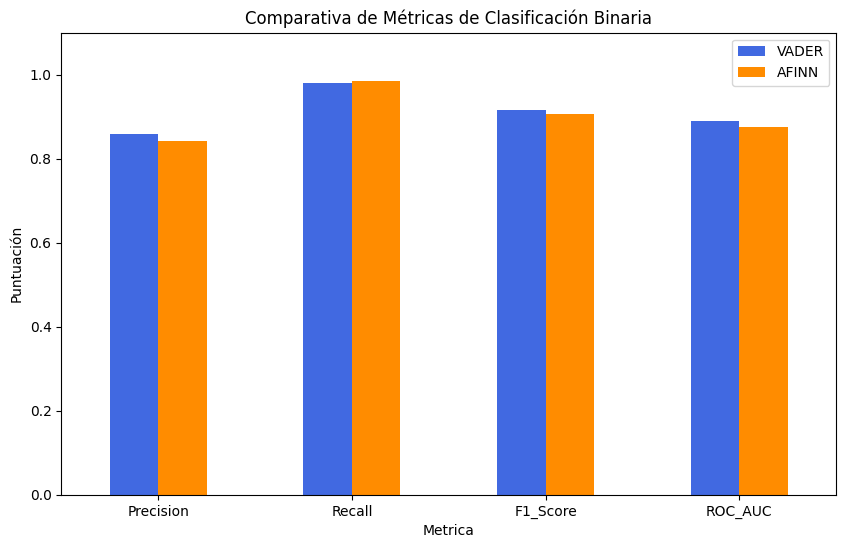

Métricas clasificación multiclase VADER:
Accuracy: 0.767 | Macro F1: 0.529
Precision por clase -> Negativo: 0.850, Neutro: 0.163, Positivo: 0.789

Métricas clasificación multiclase AFINN:
Accuracy: 0.750 | Macro F1: 0.498
Precision por clase -> Negativo: 0.877, Neutro: 0.125, Positivo: 0.771


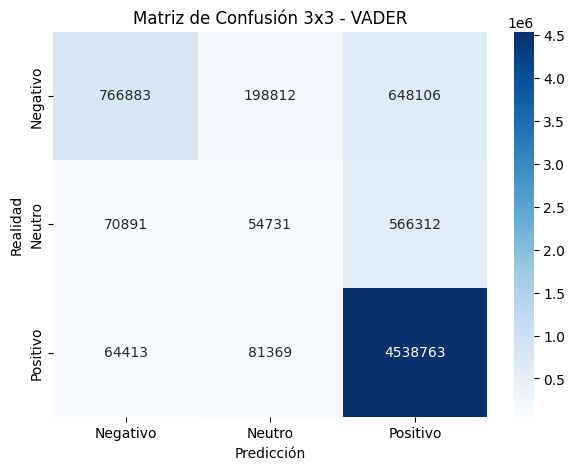

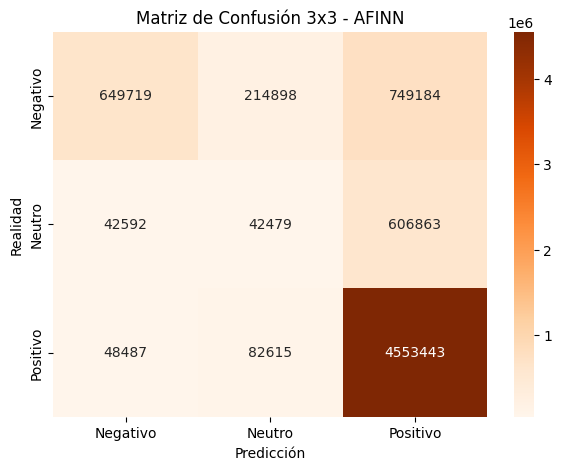

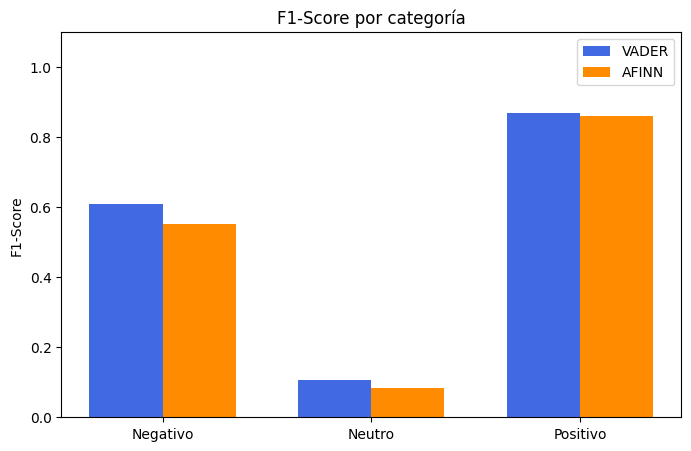

In [32]:
csv_scored = '../results/yelp_academic_dataset_review_scored.csv'

regression_metrics(csv_scored)
binary_classification_metrics(csv_scored)
multiclass_classification_metrics(csv_scored)